# Visualization
**Kecerdasan Buatan**

Nama: Mikhael Josua Roganda     
NIM: 42324023

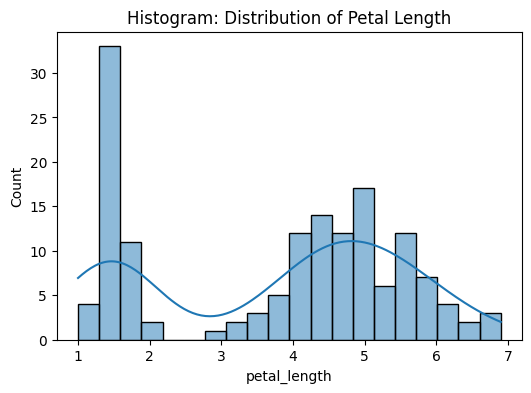

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# load the dataset
df = sns.load_dataset('iris')

# 1. Histogram - distribusi 
plt.figure(figsize=(6, 4))
sns.histplot(df['petal_length'], bins=20, kde=True)
plt.title('Histogram: Distribution of Petal Length')
plt.show()

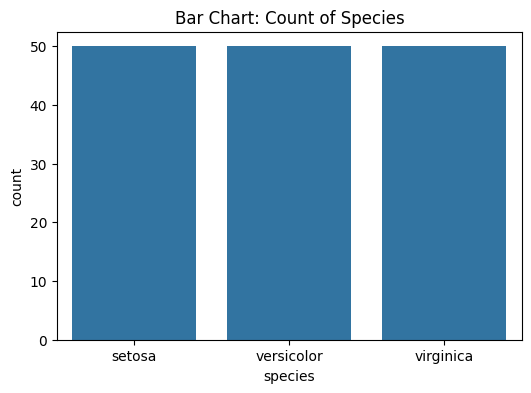

In [4]:
# 2. Bar Chart - count per category
plt.figure(figsize=(6, 4))
sns.countplot(x='species', data=df)
plt.title('Bar Chart: Count of Species')
plt.show()

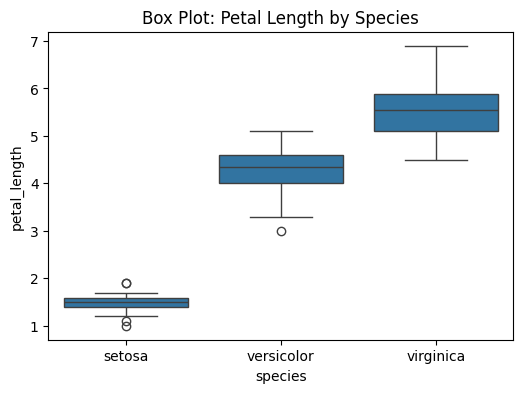

In [5]:
# 3. Box plot - spread + outlier detection
plt.figure(figsize=(6, 4))
sns.boxplot(x='species', y='petal_length', data=df)
plt.title('Box Plot: Petal Length by Species')
plt.show()

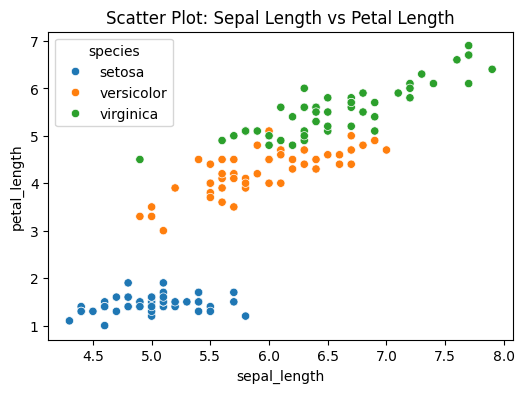

In [6]:
# 4. Scatter plot - Relationship
plt.figure(figsize=(6, 4))
sns.scatterplot(x='sepal_length', y='petal_length', hue='species', data=df)
plt.title('Scatter Plot: Sepal Length vs Petal Length')
plt.show()

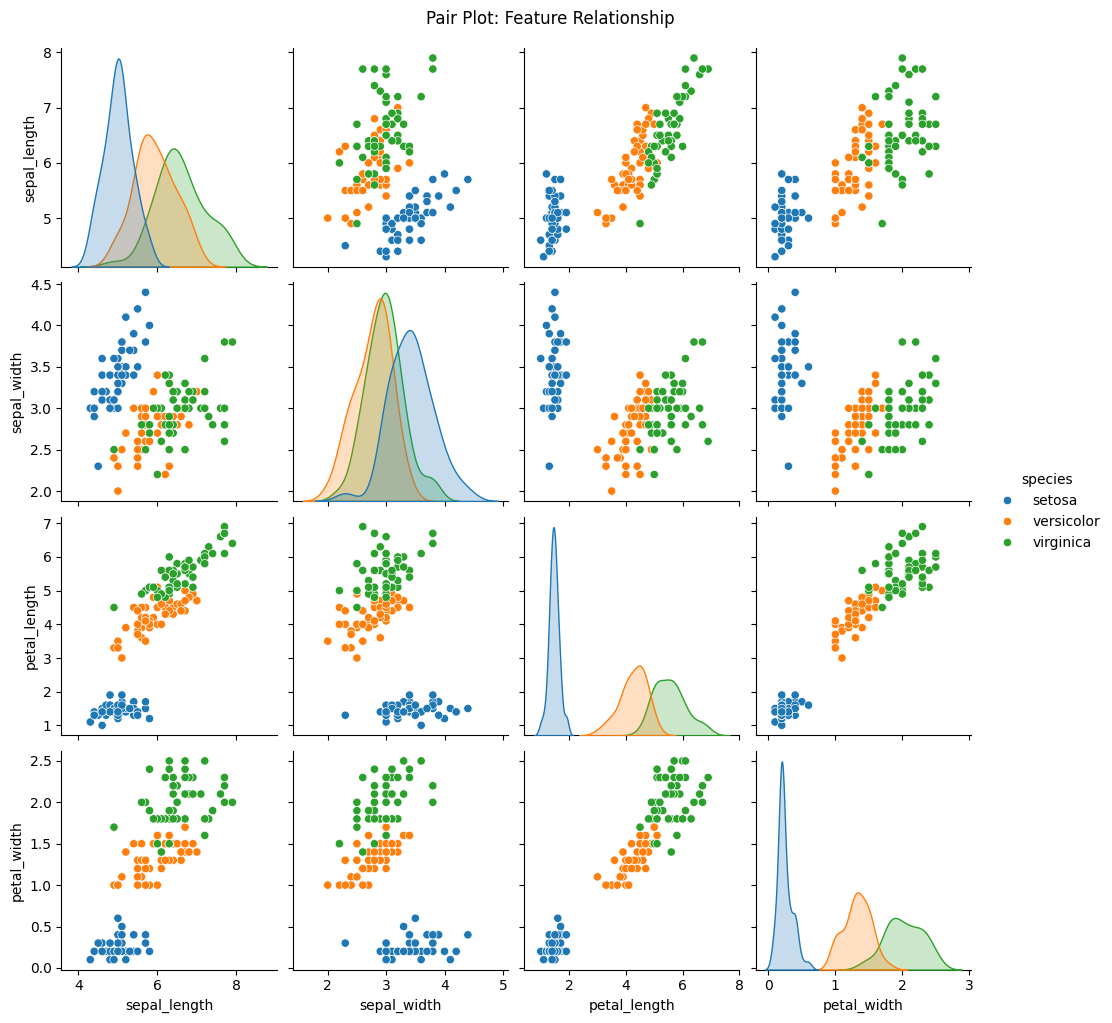

In [7]:
# 5. Pair plot - Multivariate relationships
sns.pairplot(df, hue='species')
plt.suptitle('Pair Plot: Feature Relationship', y=1.02)
plt.show()

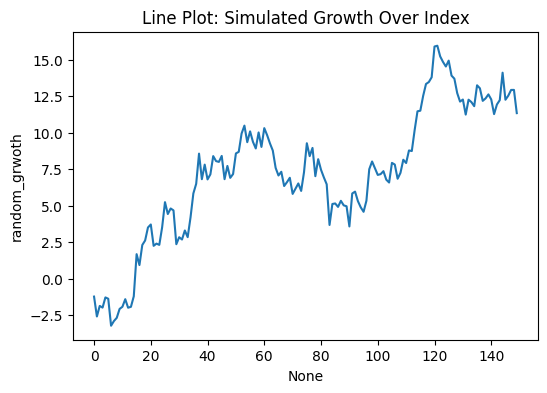

In [8]:
# 6. Line plot - example time series (simulate cumulative sum)
plt.figure(figsize=(6, 4))
df["random_grwoth"] = np.random.randn(len(df)).cumsum()
sns.lineplot(x=df.index, y='random_grwoth', data=df)
plt.title('Line Plot: Simulated Growth Over Index')
plt.show()

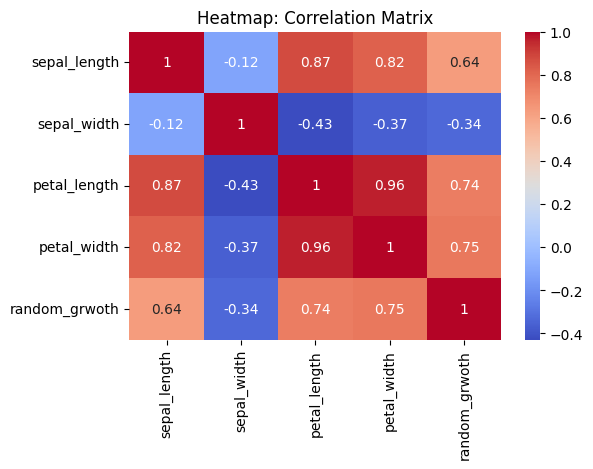

In [9]:
# 7. Heatmap - correlation matrix
plt.figure(figsize=(6, 4))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap: Correlation Matrix')
plt.show()

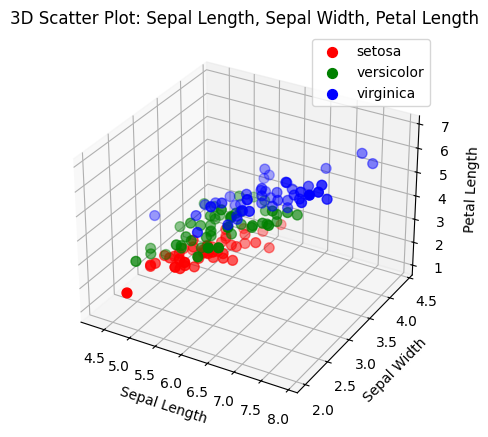

In [10]:
# 8. 3D Scatter Plot - 3 features visualization
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

species = df['species'].unique()
colors = ['r', 'g', 'b']

for sp, col in zip(species, colors):
    subset = df[df['species'] == sp]
    ax.scatter(subset['sepal_length'], subset['sepal_width'], subset['petal_length'], c=col, label=sp, s=50)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('3D Scatter Plot: Sepal Length, Sepal Width, Petal Length')
ax.legend()
plt.show()

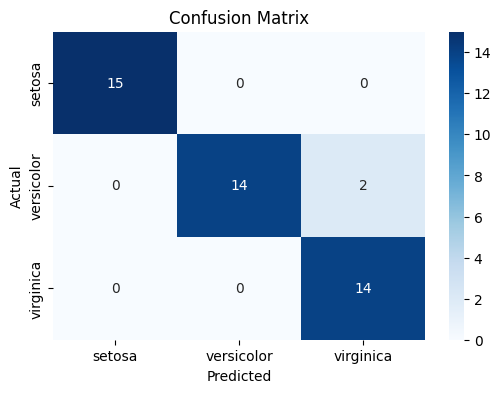

In [19]:
import seaborn as sns

# 9. Model-Specific Visualization (e.g Modeling using RandomForest)
# Split data
# Use existing df if already defined in the notebook; otherwise load the dataset.
if 'df' not in globals():
    df = sns.load_dataset('iris')

X = df.drop("species", axis=1)
y = df["species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=55)
# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
# 9.1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

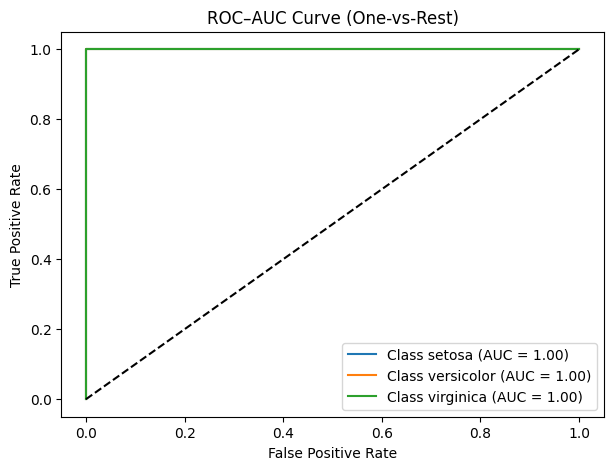

In [21]:
# 9.2. ROC–AUC Curve (multi-class with One-vs-Rest)
# Binarize labels
y_bin = label_binarize(y, classes=model.classes_)
n_classes = y_bin.shape[1]
# Train OvR classifier
ovr_model = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
ovr_model.fit(X_train, label_binarize(y_train, classes=model.classes_))
y_score = ovr_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=model.classes_)
# Plot ROC curve
plt.figure(figsize=(7,5))
for i in range(n_classes):
 fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
 roc_auc = auc(fpr, tpr)
 plt.plot(fpr, tpr, label=f"Class {model.classes_[i]} (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], "k--") # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve (One-vs-Rest)")
plt.legend()
plt.show()


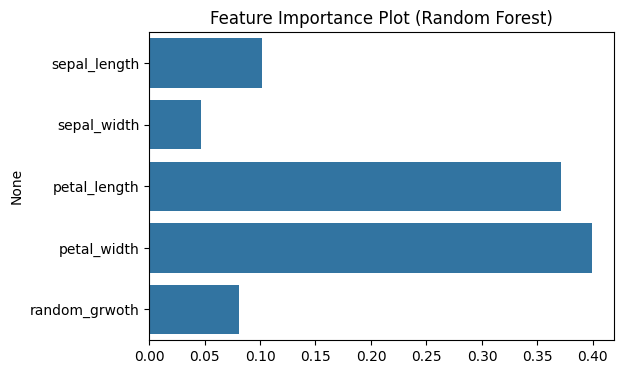

In [39]:
# 9.3. Feature Importance Plot → Random Forest
X = df.drop("species", axis=1)
y = df["species"]
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)
importances = model.feature_importances_
features = X.columns
plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance Plot (Random Forest)")
plt.show()
